In [2]:
from pathlib import Path
import shutil
import csv
import re
from collections import defaultdict

In [3]:
ROOT = Path(
    r"F:\Datasets\VisioDECT Scenario-Based Multi-Drone Detection\VisioDECT Dataset Upload"
)

OUTPUT = Path(
    r"F:\Datasets\VisioDECT_YOLO_Unified"
)

OUT_IMAGES = OUTPUT / "images" / "all"
OUT_LABELS = OUTPUT / "labels" / "all"

OUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUT_LABELS.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Root exists:", ROOT.exists())
print("Output folder:", OUTPUT)

Root exists: True
Output folder: F:\Datasets\VisioDECT_YOLO_Unified


In [4]:
def safe_name(text: str) -> str:
    """
    Converts text into a safe filename component.
    """
    text = text.replace(" ", "_")
    text = re.sub(r"[^A-Za-z0-9_\-()]+", "_", text)
    text = re.sub(r"_+", "_", text)
    return text.strip("_")


def find_case_insensitive_dir(parent: Path, wanted_name: str):
    """
    Find a directory inside parent matching wanted_name case-insensitively.
    Example: wanted 'cloudy' can match 'Cloudy'.
    """
    if parent is None or not parent.exists():
        return None

    wanted_lower = wanted_name.lower()

    for child in parent.iterdir():
        if child.is_dir() and child.name.lower() == wanted_lower:
            return child

    return None


def find_csv_file(label_scenario_dir: Path):
    """
    Find a CSV file inside a scenario label directory.
    """
    if label_scenario_dir is None or not label_scenario_dir.exists():
        return None

    csv_files = list(label_scenario_dir.glob("*.csv"))

    if len(csv_files) > 0:
        return csv_files[0]

    return None


def find_txt_label(label_scenario_dir: Path, image_stem: str):
    """
    Try to find the YOLO txt label for an image.

    Supports possible structures:
    labels/Sunny/txt/image.txt
    labels/Sunny/image.txt
    """
    if label_scenario_dir is None or not label_scenario_dir.exists():
        return None

    candidates = []

    txt_dir = find_case_insensitive_dir(label_scenario_dir, "txt")

    if txt_dir is not None:
        candidates.append(txt_dir / f"{image_stem}.txt")

    candidates.append(label_scenario_dir / f"{image_stem}.txt")

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return None

In [5]:
def read_yolo_txt(txt_path: Path):
    """
    Read YOLO txt file.

    Expected format:
    class_id x_center y_center width height

    Coordinates should be normalized between 0 and 1.

    For MVP 1:
    all class IDs are remapped to 0 = drone.
    """
    lines_out = []
    invalid_lines = []

    with open(txt_path, "r", encoding="utf-8", errors="ignore") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 5:
                invalid_lines.append((line_number, line, "Expected 5 values"))
                continue

            old_class, xc, yc, w, h = parts

            try:
                xc = float(xc)
                yc = float(yc)
                w = float(w)
                h = float(h)
            except ValueError:
                invalid_lines.append((line_number, line, "Non-numeric YOLO coordinate"))
                continue

            if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
                invalid_lines.append((line_number, line, "YOLO values are invalid or not normalized"))
                continue

            lines_out.append(f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

    return lines_out, invalid_lines

In [6]:
def read_csv_labels(csv_path: Path):
    """
    Read CSV labels.

    Expected CSV format:
    class_name, x, y, width, height, image_name, image_width, image_height

    CSV bbox format:
    absolute xywh

    Returns:
    labels_by_image[image_name] = list of YOLO label lines
    """
    labels_by_image = defaultdict(list)
    invalid_rows = []

    with open(csv_path, "r", encoding="utf-8-sig", errors="ignore", newline="") as f:
        reader = csv.reader(f)

        for row_number, row in enumerate(reader, start=1):
            if not row:
                continue

            if len(row) < 8:
                invalid_rows.append((row_number, row, "Expected at least 8 columns"))
                continue

            class_name = row[0]
            x = row[1]
            y = row[2]
            w = row[3]
            h = row[4]
            image_name = row[5]
            image_width = row[6]
            image_height = row[7]

            try:
                x = float(x)
                y = float(y)
                w = float(w)
                h = float(h)
                image_width = float(image_width)
                image_height = float(image_height)
            except ValueError:
                invalid_rows.append((row_number, row, "Non-numeric bbox/image size"))
                continue

            if image_width <= 0 or image_height <= 0 or w <= 0 or h <= 0:
                invalid_rows.append((row_number, row, "Invalid bbox/image size"))
                continue

            # Convert absolute xywh to YOLO normalized center xywh
            x_center = (x + w / 2) / image_width
            y_center = (y + h / 2) / image_height
            yolo_w = w / image_width
            yolo_h = h / image_height

            if not (
                0 <= x_center <= 1
                and 0 <= y_center <= 1
                and 0 < yolo_w <= 1
                and 0 < yolo_h <= 1
            ):
                invalid_rows.append((row_number, row, "Converted YOLO values invalid"))
                continue

            yolo_line = f"0 {x_center:.6f} {y_center:.6f} {yolo_w:.6f} {yolo_h:.6f}"

            labels_by_image[image_name].append(yolo_line)

    return labels_by_image, invalid_rows

In [7]:
drone_dirs = [p for p in ROOT.iterdir() if p.is_dir()]

print("Drone/model folders found:")
for d in drone_dirs:
    print("-", d.name)

Drone/model folders found:
- Anafi-Extended
- DJIFPV
- DJIPhantom
- EFT-E410S
- Mavic_Air
- Mavic_Enterprise
- .venv


In [8]:
manifest_rows = []
missing_label_rows = []
invalid_label_rows = []

total_images_seen = 0
total_images_copied = 0
used_txt = 0
used_csv = 0
missing_labels = 0
total_boxes = 0

for drone_dir in drone_dirs:
    model_name = drone_dir.name

    images_root = drone_dir / "images"
    labels_root = drone_dir / "labels"

    if not images_root.exists():
        print(f"[SKIP] No images folder found for {model_name}")
        continue

    scenario_dirs = [p for p in images_root.iterdir() if p.is_dir()]

    for image_scenario_dir in scenario_dirs:
        scenario_name = image_scenario_dir.name

        label_scenario_dir = find_case_insensitive_dir(labels_root, scenario_name)

        csv_labels_by_image = {}
        csv_invalid_rows = []

        csv_path = find_csv_file(label_scenario_dir)

        if csv_path is not None:
            csv_labels_by_image, csv_invalid_rows = read_csv_labels(csv_path)

            for row_number, row, reason in csv_invalid_rows:
                invalid_label_rows.append({
                    "model": model_name,
                    "scenario": scenario_name,
                    "source": str(csv_path),
                    "line_or_row": row_number,
                    "content": str(row),
                    "reason": reason,
                })

        image_paths = [
            p for p in image_scenario_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS
        ]

        print(f"[INFO] {model_name}/{scenario_name}: {len(image_paths)} images")

        for image_path in image_paths:
            total_images_seen += 1

            original_image_name = image_path.name
            original_stem = image_path.stem

            group = f"{model_name}/{scenario_name}"

            new_stem = safe_name(f"{model_name}__{scenario_name}__{original_stem}")
            new_image_name = new_stem + image_path.suffix.lower()
            new_label_name = new_stem + ".txt"

            out_image_path = OUT_IMAGES / new_image_name
            out_label_path = OUT_LABELS / new_label_name

            label_lines = []
            label_source = None

            # First choice: YOLO txt
            txt_path = find_txt_label(label_scenario_dir, original_stem)

            if txt_path is not None:
                label_lines, txt_invalid_lines = read_yolo_txt(txt_path)
                label_source = str(txt_path)
                used_txt += 1

                for line_number, line, reason in txt_invalid_lines:
                    invalid_label_rows.append({
                        "model": model_name,
                        "scenario": scenario_name,
                        "source": str(txt_path),
                        "line_or_row": line_number,
                        "content": line,
                        "reason": reason,
                    })

            # Second choice: CSV fallback
            elif original_image_name in csv_labels_by_image:
                label_lines = csv_labels_by_image[original_image_name]
                label_source = str(csv_path)
                used_csv += 1

            # Missing label
            else:
                missing_labels += 1
                missing_label_rows.append({
                    "model": model_name,
                    "scenario": scenario_name,
                    "original_image": original_image_name,
                    "image_path": str(image_path),
                    "expected_txt_stem": original_stem + ".txt",
                    "csv_path": str(csv_path) if csv_path else "",
                })
                continue

            if not label_lines:
                missing_labels += 1
                missing_label_rows.append({
                    "model": model_name,
                    "scenario": scenario_name,
                    "original_image": original_image_name,
                    "image_path": str(image_path),
                    "expected_txt_stem": original_stem + ".txt",
                    "csv_path": str(csv_path) if csv_path else "",
                })
                continue

            shutil.copy2(image_path, out_image_path)

            with open(out_label_path, "w", encoding="utf-8") as f:
                f.write("\n".join(label_lines) + "\n")

            total_boxes += len(label_lines)
            total_images_copied += 1

            manifest_rows.append({
                "new_image": new_image_name,
                "new_label": new_label_name,
                "original_image": original_image_name,
                "model": model_name,
                "scenario": scenario_name,
                "group": group,
                "label_source": label_source,
                "num_boxes": len(label_lines),
            })

print("Merge finished.")

[INFO] Anafi-Extended/Cloudy: 1200 images
[INFO] Anafi-Extended/Evening: 1200 images
[INFO] Anafi-Extended/Sunny: 1071 images
[INFO] DJIFPV/Cloudy: 1200 images
[INFO] DJIFPV/Evening: 1200 images
[INFO] DJIFPV/Sunny: 1200 images
[INFO] DJIPhantom/Cloudy: 900 images
[INFO] DJIPhantom/Evening: 1200 images
[INFO] DJIPhantom/Sunny: 1200 images
[INFO] EFT-E410S/Cloudy: 1200 images
[INFO] EFT-E410S/Evening: 1200 images
[INFO] EFT-E410S/Sunny: 1200 images
[INFO] Mavic_Air/Cloudy: 1165 images
[INFO] Mavic_Air/Evening: 1165 images
[INFO] Mavic_Air/Sunny: 1191 images
[INFO] Mavic_Enterprise/Cloudy: 1188 images
[INFO] Mavic_Enterprise/Evening: 1102 images
[INFO] Mavic_Enterprise/Sunny: 1142 images
[SKIP] No images folder found for .venv
Merge finished.


In [9]:
manifest_path = OUTPUT / "manifest.csv"
missing_path = OUTPUT / "missing_labels.csv"
invalid_path = OUTPUT / "invalid_labels.csv"

with open(manifest_path, "w", encoding="utf-8", newline="") as f:
    fieldnames = [
        "new_image",
        "new_label",
        "original_image",
        "model",
        "scenario",
        "group",
        "label_source",
        "num_boxes",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(manifest_rows)

with open(missing_path, "w", encoding="utf-8", newline="") as f:
    fieldnames = [
        "model",
        "scenario",
        "original_image",
        "image_path",
        "expected_txt_stem",
        "csv_path",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(missing_label_rows)

with open(invalid_path, "w", encoding="utf-8", newline="") as f:
    fieldnames = [
        "model",
        "scenario",
        "source",
        "line_or_row",
        "content",
        "reason",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(invalid_label_rows)

print("Saved:")
print(manifest_path)
print(missing_path)
print(invalid_path)

Saved:
F:\Datasets\VisioDECT_YOLO_Unified\manifest.csv
F:\Datasets\VisioDECT_YOLO_Unified\missing_labels.csv
F:\Datasets\VisioDECT_YOLO_Unified\invalid_labels.csv


In [10]:
data_yaml_path = OUTPUT / "data.yaml"

with open(data_yaml_path, "w", encoding="utf-8") as f:
    f.write(
        "path: " + str(OUTPUT).replace("\\", "/") + "\n"
        "train: images/all\n"
        "val: images/all\n"
        "test: images/all\n"
        "names:\n"
        "  0: drone\n"
    )

print("Temporary data.yaml created:")
print(data_yaml_path)

Temporary data.yaml created:
F:\Datasets\VisioDECT_YOLO_Unified\data.yaml


In [11]:
print("=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"Images seen:          {total_images_seen}")
print(f"Images copied:        {total_images_copied}")
print(f"Total boxes:          {total_boxes}")
print(f"Used YOLO txt labels: {used_txt}")
print(f"Used CSV labels:      {used_csv}")
print(f"Missing labels:       {missing_labels}")
print(f"Invalid label rows:   {len(invalid_label_rows)}")
print()
print(f"Unified images:       {OUT_IMAGES}")
print(f"Unified labels:       {OUT_LABELS}")
print(f"Manifest:             {manifest_path}")
print(f"Missing labels file:  {missing_path}")
print(f"Invalid labels file:  {invalid_path}")
print(f"Temporary data.yaml:  {data_yaml_path}")

SUMMARY
Images seen:          20924
Images copied:        20617
Total boxes:          20620
Used YOLO txt labels: 18305
Used CSV labels:      2312
Missing labels:       307
Invalid label rows:   2

Unified images:       F:\Datasets\VisioDECT_YOLO_Unified\images\all
Unified labels:       F:\Datasets\VisioDECT_YOLO_Unified\labels\all
Manifest:             F:\Datasets\VisioDECT_YOLO_Unified\manifest.csv
Missing labels file:  F:\Datasets\VisioDECT_YOLO_Unified\missing_labels.csv
Invalid labels file:  F:\Datasets\VisioDECT_YOLO_Unified\invalid_labels.csv
Temporary data.yaml:  F:\Datasets\VisioDECT_YOLO_Unified\data.yaml


In [12]:
images = list((OUTPUT / "images" / "all").glob("*.*"))
labels = list((OUTPUT / "labels" / "all").glob("*.txt"))

image_stems = {p.stem for p in images}
label_stems = {p.stem for p in labels}

images_without_labels = image_stems - label_stems
labels_without_images = label_stems - image_stems

print("Images:", len(images))
print("Labels:", len(labels))
print("Images without labels:", len(images_without_labels))
print("Labels without images:", len(labels_without_images))

print("\nSample images without labels:")
print(list(images_without_labels)[:10])

print("\nSample labels without images:")
print(list(labels_without_images)[:10])

Images: 20617
Labels: 20617
Images without labels: 0
Labels without images: 0

Sample images without labels:
[]

Sample labels without images:
[]


In [16]:
import sys
!{sys.executable} -m pip install pandas

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
     -------------------------------------- 510.1/510.1 kB 1.5 MB/s eta 0:00:00
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
     -------------------------------------- 349.3/349.3 kB 2.7 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd

manifest_df = pd.read_csv(OUTPUT / "manifest.csv")

manifest_df.head()

,new_image,new_label,original_image,model,scenario,group,label_source,num_boxes
0,Anafi-Extended_Cloudy_Anafi_Extended_Cloudy_(1...,Anafi-Extended_Cloudy_Anafi_Extended_Cloudy_(1...,Anafi_Extended_Cloudy (1).jpg,Anafi-Extended,Cloudy,Anafi-Extended/Cloudy,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,1
1,Anafi-Extended_Cloudy_Anafi_Extended_Cloudy_(1...,Anafi-Extended_Cloudy_Anafi_Extended_Cloudy_(1...,Anafi_Extended_Cloudy (10).jpg,Anafi-Extended,Cloudy,Anafi-Extended/Cloudy,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,1
2,Anafi-Extended_Cloudy_Anafi_Extended_Cloudy_(1...,Anafi-Extended_Cloudy_Anafi_Extended_Cloudy_(1...,Anafi_Extended_Cloudy (100).jpg,Anafi-Extended,Cloudy,Anafi-Extended/Cloudy,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,1
3,Anafi-Extended_Cloudy_Anafi_Extended_Cloudy_(1...,Anafi-Extended_Cloudy_Anafi_Extended_Cloudy_(1...,Anafi_Extended_Cloudy (1000).jpg,Anafi-Extended,Cloudy,Anafi-Extended/Cloudy,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,1
4,Anafi-Extended_Cloudy_Anafi_Extended_Cloudy_(1...,Anafi-Extended_Cloudy_Anafi_Extended_Cloudy_(1...,Anafi_Extended_Cloudy (1001).jpg,Anafi-Extended,Cloudy,Anafi-Extended/Cloudy,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,1


In [18]:
manifest_df.groupby(["model", "scenario"]).size().reset_index(name="num_images")

,model,scenario,num_images
0,Anafi-Extended,Cloudy,1200
1,Anafi-Extended,Evening,1200
2,Anafi-Extended,Sunny,989
3,DJIFPV,Cloudy,1112
4,DJIFPV,Evening,1127
5,DJIFPV,Sunny,1200
6,DJIPhantom,Cloudy,900
7,DJIPhantom,Evening,1200
8,DJIPhantom,Sunny,1200
9,EFT-E410S,Cloudy,1200


In [23]:
import sys
!{sys.executable} -m pip install opencv-python matplotlib

     -------------------------------------- 44.0/44.0 MB 319.3 kB/s eta 0:00:00
     ---------------------------------------- 8.2/8.2 MB 880.9 kB/s eta 0:00:00
     ---------------------------------------- 1.6/1.6 MB 548.0 kB/s eta 0:00:00
     ------------------------------------ 122.8/122.8 kB 554.4 kB/s eta 0:00:00
     -------------------------------------- 73.4/73.4 kB 579.3 kB/s eta 0:00:00
     ---------------------------------------- 7.2/7.2 MB 163.2 kB/s eta 0:00:00
     ------------------------------------ 221.2/221.2 kB 300.1 kB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


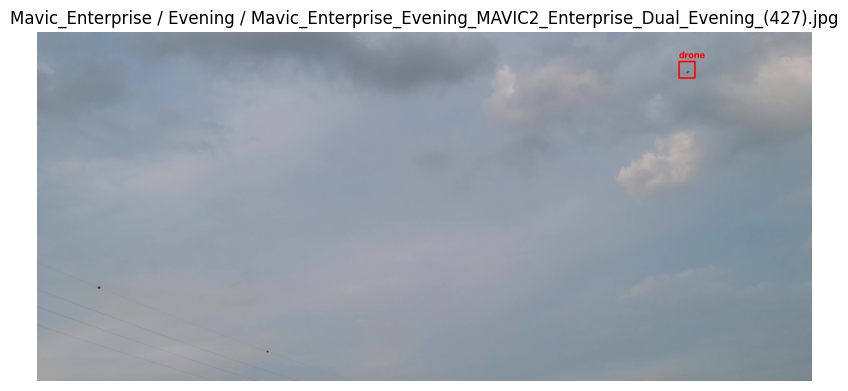

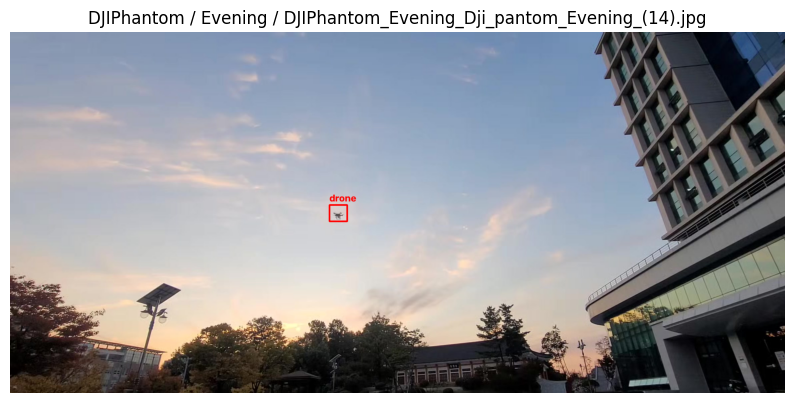

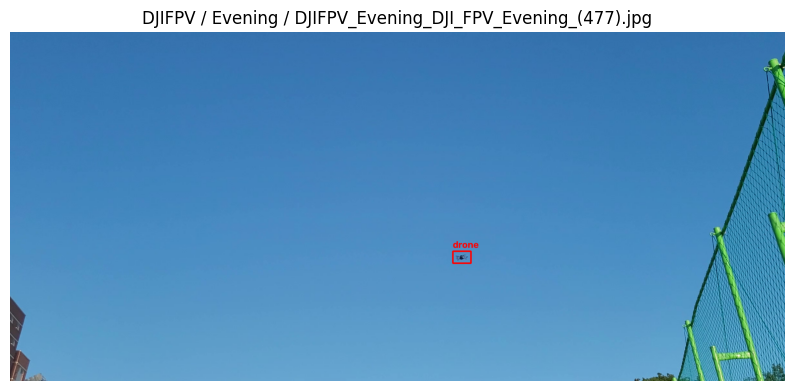

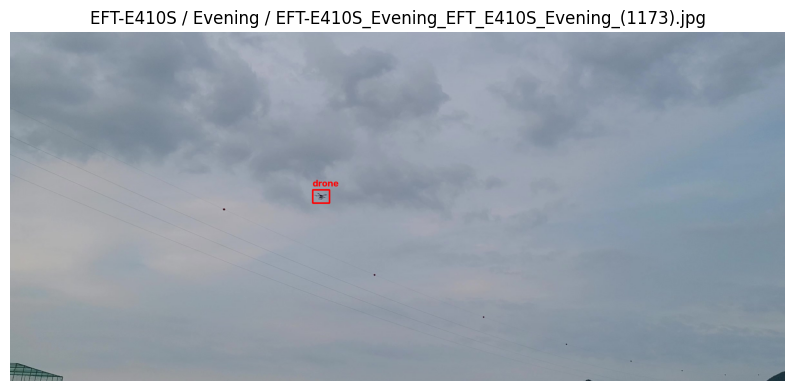

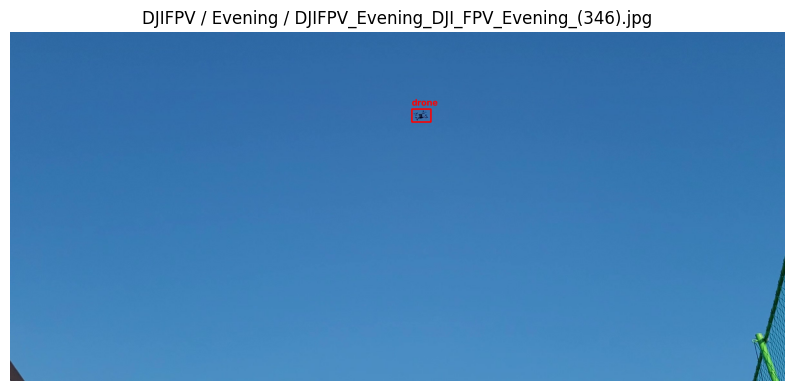

In [24]:
import random
import cv2
from matplotlib import pyplot as plt

def draw_yolo_box(image_path: Path, label_path: Path):
    image = cv2.imread(str(image_path))
    
    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
        
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    with open(label_path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    for line in lines:
        class_id, xc, yc, bw, bh = line.split()
        xc = float(xc)
        yc = float(yc)
        bw = float(bw)
        bh = float(bh)

        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(
            image,
            "drone",
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255, 0, 0),
            2,
        )

    return image


sample_rows = manifest_df.sample(5, random_state=42)

for _, row in sample_rows.iterrows():
    image_path = OUT_IMAGES / row["new_image"]
    label_path = OUT_LABELS / row["new_label"]

    img = draw_yolo_box(image_path, label_path)

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title(f'{row["model"]} / {row["scenario"]} / {row["new_image"]}')
    plt.axis("off")
    plt.show()

In [25]:

missing_df = pd.read_csv(OUTPUT / "missing_labels.csv")

print("Missing rows:", len(missing_df))

missing_df.groupby(["model", "scenario"]).size().reset_index(name="missing_count")

Missing rows: 307


,model,scenario,missing_count
0,Anafi-Extended,Sunny,82
1,DJIFPV,Cloudy,88
2,DJIFPV,Evening,73
3,EFT-E410S,Evening,48
4,Mavic_Air,Evening,2
5,Mavic_Enterprise,Evening,4
6,Mavic_Enterprise,Sunny,10


In [26]:
missing_df.head(20)

,model,scenario,original_image,image_path,expected_txt_stem,csv_path
0,Anafi-Extended,Sunny,Anafi_Extended_sunny (1000).jpg,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,Anafi_Extended_sunny (1000).txt,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...
1,Anafi-Extended,Sunny,Anafi_Extended_sunny (1001).jpg,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,Anafi_Extended_sunny (1001).txt,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...
2,Anafi-Extended,Sunny,Anafi_Extended_sunny (1002).jpg,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,Anafi_Extended_sunny (1002).txt,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...
3,Anafi-Extended,Sunny,Anafi_Extended_sunny (1003).jpg,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,Anafi_Extended_sunny (1003).txt,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...
4,Anafi-Extended,Sunny,Anafi_Extended_sunny (1004).jpg,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,Anafi_Extended_sunny (1004).txt,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...
5,Anafi-Extended,Sunny,Anafi_Extended_sunny (1005).jpg,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,Anafi_Extended_sunny (1005).txt,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...
6,Anafi-Extended,Sunny,Anafi_Extended_sunny (1006).jpg,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,Anafi_Extended_sunny (1006).txt,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...
7,Anafi-Extended,Sunny,Anafi_Extended_sunny (1007).jpg,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,Anafi_Extended_sunny (1007).txt,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...
8,Anafi-Extended,Sunny,Anafi_Extended_sunny (1008).jpg,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,Anafi_Extended_sunny (1008).txt,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...
9,Anafi-Extended,Sunny,Anafi_Extended_sunny (1009).jpg,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...,Anafi_Extended_sunny (1009).txt,F:\Datasets\VisioDECT Scenario-Based Multi-Dro...


In [27]:
from pathlib import Path
import os

DATASET = Path(r"F:\Datasets\VisioDECT_YOLO_Unified")

IMAGES_DIR = DATASET / "images" / "all"
LABELS_DIR = DATASET / "labels" / "all"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Set this to False first to only preview what would be removed
DRY_RUN = True

images = [p for p in IMAGES_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
labels = [p for p in LABELS_DIR.iterdir() if p.is_file() and p.suffix.lower() == ".txt"]

image_stems = {p.stem: p for p in images}
label_stems = {p.stem: p for p in labels}

images_without_labels = sorted(set(image_stems.keys()) - set(label_stems.keys()))
labels_without_images = sorted(set(label_stems.keys()) - set(image_stems.keys()))

print("=" * 60)
print("YOLO DATASET CONSISTENCY CHECK")
print("=" * 60)
print("Images:", len(images))
print("Labels:", len(labels))
print("Images without labels:", len(images_without_labels))
print("Labels without images:", len(labels_without_images))

print("\nSample images without labels:")
for stem in images_without_labels[:10]:
    print(image_stems[stem])

print("\nSample labels without images:")
for stem in labels_without_images[:10]:
    print(label_stems[stem])

if DRY_RUN:
    print("\nDRY_RUN=True, so nothing was deleted.")
    print("If the results look correct, set DRY_RUN=False and rerun.")
else:
    removed_images = 0
    removed_labels = 0

    for stem in images_without_labels:
        image_stems[stem].unlink()
        removed_images += 1

    for stem in labels_without_images:
        label_stems[stem].unlink()
        removed_labels += 1

    print("\nCleanup finished.")
    print("Removed images without labels:", removed_images)
    print("Removed labels without images:", removed_labels)

YOLO DATASET CONSISTENCY CHECK
Images: 20617
Labels: 20617
Images without labels: 0
Labels without images: 0

Sample images without labels:

Sample labels without images:

DRY_RUN=True, so nothing was deleted.
If the results look correct, set DRY_RUN=False and rerun.


In [29]:
from pathlib import Path

DATASET = Path(r"F:\Datasets\VisioDECT_YOLO_Unified")

IMAGES_DIR = DATASET / "images" / "all"
LABELS_DIR = DATASET / "labels" / "all"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = [p for p in IMAGES_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
labels = [p for p in LABELS_DIR.iterdir() if p.is_file() and p.suffix.lower() == ".txt"]

image_stems = {p.stem for p in images}
label_stems = {p.stem for p in labels}

images_without_labels = image_stems - label_stems
labels_without_images = label_stems - image_stems

print("=" * 60)
print("FINAL CLEAN DATASET CHECK")
print("=" * 60)
print("Images:", len(images))
print("Labels:", len(labels))
print("Images without labels:", len(images_without_labels))
print("Labels without images:", len(labels_without_images))

if len(images_without_labels) == 0 and len(labels_without_images) == 0:
    print("\n✅ Dataset is clean. Every image has a matching label and every label has a matching image.")
else:
    print("\n⚠️ Dataset still has mismatches.")
    print("\nSample images without labels:")
    print(list(images_without_labels)[:10])
    print("\nSample labels without images:")
    print(list(labels_without_images)[:10])

FINAL CLEAN DATASET CHECK
Images: 20617
Labels: 20617
Images without labels: 0
Labels without images: 0

✅ Dataset is clean. Every image has a matching label and every label has a matching image.


In [2]:
from pathlib import Path
import random
import csv

OUTPUT = Path(r"F:\Datasets\VisioDECT_YOLO_Unified")

OUT_IMAGES = OUTPUT / "images" / "all"
OUT_LABELS = OUTPUT / "labels" / "all"

MANIFEST_PATH = OUTPUT / "manifest.csv"
MISSING_PATH = OUTPUT / "missing_labels.csv"
INVALID_PATH = OUTPUT / "invalid_labels.csv"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Output exists:", OUTPUT.exists())
print("Images folder exists:", OUT_IMAGES.exists())
print("Labels folder exists:", OUT_LABELS.exists())
print("Manifest exists:", MANIFEST_PATH.exists())
print("Missing labels report exists:", MISSING_PATH.exists())
print("Invalid labels report exists:", INVALID_PATH.exists())

Output exists: True
Images folder exists: True
Labels folder exists: True
Manifest exists: True
Missing labels report exists: True
Invalid labels report exists: True


In [3]:
images = [p for p in OUT_IMAGES.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
labels = [p for p in OUT_LABELS.iterdir() if p.is_file() and p.suffix.lower() == ".txt"]

image_stems = {p.stem for p in images}
label_stems = {p.stem for p in labels}

print("Images:", len(images))
print("Labels:", len(labels))
print("Images without labels:", len(image_stems - label_stems))
print("Labels without images:", len(label_stems - image_stems))

Images: 20617
Labels: 20617
Images without labels: 0
Labels without images: 0
